# Fig F. Duration of Fugl-Meyer assessment videos by item section

Regenerates the two-panel duration figure: **median** (left) and **95-percentile** (right)
video duration in seconds, grouped by Fugl-Meyer (FMA-UE) item section. The dotted line is
the mean of the per-section bar heights across **all sections except Coord./Speed**.

Videos come from the IA `question_view` set via `load_sria2_3_30` (items 3-17, 19-30) and
`load_sria2_31_33` (items 31-33), i.e. `IA_VIDEO_METADATA_PATH2` filtered to `TEST_PATIENTS`.

In [1]:
%load_ext autoreload
%autoreload 2
%cd ../..

/gpfs/data/schambralab/quantitativeRehabilitation/__lab_member_homes/victor/strokerehab_2025/vlms4rehab


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lmms_eval.tasks.strokerehab.utils_impairment_analysis import (
    load_sria2_3_30,
    load_sria2_31_33,
)

In [3]:
# --- load the question-view videos used in the IA experiments ---
df = pd.concat(
    [
        load_sria2_3_30()["test"].to_pandas(),
        load_sria2_31_33()["test"].to_pandas(),
    ],
    ignore_index=True,
)


# --- map each FM item to its Fugl-Meyer (FMA-UE) section ---
def fm_section(item):
    if 3 <= item <= 8:
        return "Arm (FS)"   # flexor synergy
    if 9 <= item <= 11:
        return "Arm (ES)"   # extensor synergy
    if 12 <= item <= 14:
        return "Arm (MCS)"  # movement combining synergies
    if 15 <= item <= 17:
        return "Arm (MOS)"  # movement out of synergy
    if 19 <= item <= 23:
        return "Wrist"
    if 24 <= item <= 30:
        return "Hand"
    if 31 <= item <= 33:
        return "Coord./Speed"
    return None


# fm_low == fm_high for individual items; grouped ranges (3-8, 9-11, ...) map to one section
df["section"] = df["fm_low"].map(fm_section)
assert df["section"].notna().all(), df[df["section"].isna()]["fm_low"].unique()
print(f"{len(df)} videos across {df['section'].nunique()} sections")
df.groupby("section")["duration"].agg(["count", "median", lambda s: s.quantile(0.95)])

665 videos across 7 sections


,count,median,<lambda_0>
section,,,
Arm (ES),29,2.566992,10.200000
Arm (FS),58,4.366992,9.766992
Arm (MCS),87,2.633008,7.030000
Arm (MOS),115,2.900000,7.866992
Coord./Speed,58,9.616992,16.205000
Hand,174,3.766992,13.885098
Wrist,144,3.066992,11.125000


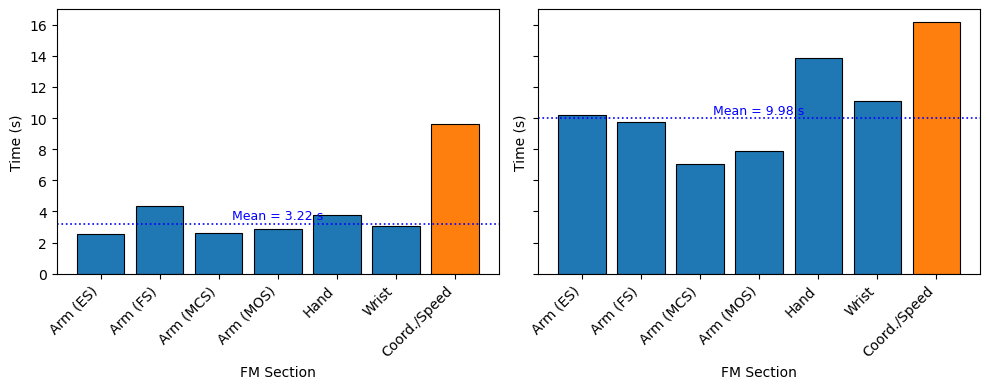

In [7]:
SECTION_ORDER = [
    "Arm (ES)",
    "Arm (FS)",
    "Arm (MCS)",
    "Arm (MOS)",
    "Hand",
    "Wrist",
    "Coord./Speed",
]
COORD = "Coord./Speed"

# per-panel: (per-section statistic over durations, label format for the mean line)
PANELS = {
    "Median": (df.groupby("section")["duration"].median(), "{:.2f}"),
    "95-percentile": (df.groupby("section")["duration"].quantile(0.95), "{:.2f}"),
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (label, (stat, fmt)) in zip(axes, PANELS.items()):
    vals = [stat[s] for s in SECTION_ORDER]
    colors = ["tab:orange" if s == COORD else "tab:blue" for s in SECTION_ORDER]
    ax.bar(range(len(SECTION_ORDER)), vals, color=colors, edgecolor="black", linewidth=0.8)

    # dotted line = mean of the per-section bar heights, excluding Coord./Speed
    mean_val = float(np.mean([stat[s] for s in SECTION_ORDER if s != COORD]))
    ax.axhline(mean_val, ls=":", color="blue", lw=1.2)
    ax.text(
        0.5,
        mean_val + 0.3,
        f"Mean = {fmt.format(mean_val)} s",
        color="blue",
        fontsize=9,
        ha="center",
        transform=ax.get_yaxis_transform(),
    )

    ax.set_xticks(range(len(SECTION_ORDER)))
    ax.set_xticklabels(SECTION_ORDER, rotation=45, ha="right")
    ax.set_xlabel("FM Section")
    ax.set_ylabel("Time (s)")

plt.tight_layout()
plt.savefig("fm_section_durations.pdf", bbox_inches="tight", dpi=300)
plt.show()